# NLP Comparison: Traditional Libraries vs LLM (Gemini)

**Before running this notebook:**
1. Run `python traditional_nlp.py` (produces `results/*.csv`)
2. Run `python export_for_llm.py` (produces `llm_input/*.csv`)
3. Use prompts from `prompts.md` in Google AI Studio, save outputs to `llm_output/*.csv`

In [77]:
import os
import csv
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

def load_csv(path):
    """Load a CSV file as a list of dicts."""
    if not os.path.exists(path):
        print(f"[!] File not found: {path}")
        return None
    with open(path, "r", encoding="utf-8") as f:
        return list(csv.DictReader(f))

def accuracy(matches, total):
    if total == 0:
        return 0.0
    return round(100 * matches / total, 1)

def classification_report_side_by_side(y_true, y_pred_trad, y_pred_llm, labels,
                                        trad_name="Traditional", llm_name="LLM (Gemini)"):
    """Build a side-by-side per-class metrics DataFrame for Traditional vs LLM."""
    rows = []
    for name, y_pred in [(trad_name, y_pred_trad), (llm_name, y_pred_llm)]:
        P, R, F1, S = precision_recall_fscore_support(y_true, y_pred, labels=labels, zero_division=0)
        P_macro, R_macro, F1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
        P_micro, R_micro, F1_micro, _ = precision_recall_fscore_support(y_true, y_pred, average="micro", zero_division=0)
        acc = accuracy_score(y_true, y_pred)
        total = sum(S)

        for i, label in enumerate(labels):
            rows.append({"Model": name, "Class": label,
                         "Precision": round(P[i], 4), "Recall": round(R[i], 4),
                         "F1-Score": round(F1[i], 4), "Support": int(S[i])})
        rows.append({"Model": name, "Class": "Macro Avg",
                     "Precision": round(P_macro, 4), "Recall": round(R_macro, 4),
                     "F1-Score": round(F1_macro, 4), "Support": int(total)})
        rows.append({"Model": name, "Class": "Micro Avg",
                     "Precision": round(P_micro, 4), "Recall": round(R_micro, 4),
                     "F1-Score": round(F1_micro, 4), "Support": int(total)})
        rows.append({"Model": name, "Class": "Accuracy",
                     "Precision": round(acc, 4), "Recall": "", "F1-Score": "", "Support": int(total)})

    df = pd.DataFrame(rows)
    # Pivot so each model is a column group
    df = df.set_index(["Class", "Model"]).unstack("Model")
    # Reorder columns: Traditional first, then LLM
    col_order = []
    for metric in ["Precision", "Recall", "F1-Score", "Support"]:
        col_order.append((metric, trad_name))
        col_order.append((metric, llm_name))
    df = df[col_order]
    return df

# Check that required folders exist
for folder in ["results", "llm_output"]:
    if os.path.isdir(folder):
        print(f"[OK] {folder}/ found")
    else:
        print(f"[!!] {folder}/ NOT found — make sure you ran the previous steps")

[OK] results/ found
[OK] llm_output/ found


---
## 1. Sentiment Analysis Comparison

In [78]:
import custom_datasets
gold = [g.strip().lower() for g in custom_datasets.sentiment_ground_truth]
total = len(gold)
print(f"Task 1 — Data Distribution ({total} samples)")
for label, cnt in sorted(Counter(gold).items()):
    print(f"  {label:>12s}: {cnt:5d}  ({cnt/total*100:.1f}%)")

Task 1 — Data Distribution (20000 samples)
      negative: 10000  (50.0%)
      positive: 10000  (50.0%)


In [79]:
trad = load_csv("results/sentiment_traditional.csv")
llm = load_csv("llm_output/sentiment.csv")

if trad and llm:
    llm_map = {row["id"]: row["label"].strip().lower() for row in llm}

    rows = []
    for row in trad:
        tid = row["id"]
        t_label = row["label"].strip().lower()
        l_label = llm_map.get(tid, "???")
        rows.append({
            "ID": tid,
            "Text": row["text"][:60] + "...",
            "Traditional (VADER)": t_label,
            "LLM (Gemini)": l_label,
            "Match": "Yes" if t_label == l_label else "No"
        })

    df_sent = pd.DataFrame(rows)
    agree = sum(1 for r in rows if r["Match"] == "Yes")
    total = len(rows)
    print(f"Agreement: {agree}/{total} ({accuracy(agree, total)}%)\n")
    display(df_sent)
else:
    print("Skipping — missing file(s)")

Agreement: 12899/20000 (64.5%)



,ID,Text,Traditional (VADER),LLM (Gemini),Match
0,1,director peter kosminsky gives these women a f...,positive,positive,Yes
1,2,what 's best about drumline is its energy ...,positive,positive,Yes
2,3,"haphazard , and inconsequential romantic ...",positive,negative,No
3,4,confident filmmaking and a pair of fascinating...,positive,positive,Yes
4,5,unfaithful ...,positive,negative,No
...,...,...,...,...,...
19995,19996,the rich performances by friel -- and especial...,positive,positive,Yes
19996,19997,"the performances are strong , though the subje...",positive,positive,Yes
19997,19998,to squeeze the action and our emotions into th...,positive,negative,No
19998,19999,i 'll buy the soundtrack . ...,positive,positive,Yes


### Sentiment accuracy vs ground truth

This cell uses `sentiment_ground_truth` from `datasets.py` to compute:
- Traditional VADER accuracy vs gold labels
- LLM (Gemini) accuracy vs the same gold labels

In [80]:
# Reload so we get the same dataset size as the pipeline (20k); otherwise the kernel
# may have a stale import with only 20 samples (old docstring said "20 sentences").
import importlib
import custom_datasets
importlib.reload(custom_datasets)
gold = [g.strip().lower() for g in custom_datasets.sentiment_ground_truth]

if trad and llm:
    trad_labels = [row["label"].strip().lower() for row in trad]
    llm_labels = [llm_map.get(row["id"], "").strip().lower() for row in trad]

    # Align lengths (CSV rows and ground truth must match; use min to avoid mismatch)
    n = min(len(gold), len(trad))
    if n < len(gold) or n < len(trad):
        print(f"Note: Using first {n} rows (gold={len(gold)}, trad={len(trad)}).\n")
    gold = gold[:n]
    trad_labels = trad_labels[:n]
    llm_labels = llm_labels[:n]
    trad_slice = trad[:n]

    trad_correct = sum(1 for t, g in zip(trad_labels, gold) if t == g)
    llm_correct = sum(1 for l, g in zip(llm_labels, gold) if l == g)
    trad_acc = accuracy(trad_correct, n)
    llm_acc = accuracy(llm_correct, n)

    print(f"Traditional (VADER) accuracy vs gold: {trad_correct}/{n} ({trad_acc}%)")
    print(f"LLM (Gemini) accuracy vs gold:       {llm_correct}/{n} ({llm_acc}%)\n")

    # Per-class metrics side-by-side
    labels_cls = ["negative", "positive"]
    print("Per-class Precision / Recall / F1 — Traditional (VADER) vs LLM (Gemini):\n")
    display(classification_report_side_by_side(
        gold, trad_labels, llm_labels, labels_cls,
        trad_name="Traditional (VADER)", llm_name="LLM (Gemini)"))

    df_sent_gold = pd.DataFrame({
        "ID": list(range(1, n + 1)),
        "Text": [r["text"] for r in trad_slice],
        "Gold Label": gold,
        "Traditional (VADER)": trad_labels,
        "LLM (Gemini)": llm_labels,
    })
    display(df_sent_gold)
else:
    print("Run the previous sentiment comparison cell first.")

Traditional (VADER) accuracy vs gold: 13271/20000 (66.4%)
LLM (Gemini) accuracy vs gold:       17668/20000 (88.3%)

Per-class Precision / Recall / F1 — Traditional (VADER) vs LLM (Gemini):



Precision                           Recall               \
Model     Traditional (VADER) LLM (Gemini) Traditional (VADER) LLM (Gemini)   
Class                                                                         
Accuracy               0.6635       0.8834                                    
Macro Avg              0.7224       0.8835              0.6635       0.8834   
Micro Avg              0.6635       0.8834              0.6635       0.8834   
negative               0.8369       0.8904              0.4063       0.8744   
positive               0.6080       0.8766              0.9208       0.8924   

                     F1-Score                          Support               
Model     Traditional (VADER) LLM (Gemini) Traditional (VADER) LLM (Gemini)  
Class                                                                        
Accuracy                                                 20000        20000  
Macro Avg              0.6397       0.8834               20000        20000  
Micro Avg              0.6635       0.8834               20000        20000  
negative                0.547       0.8823               10000        10000  
positive               0.7324       0.8844               10000        10000

,ID,Text,Gold Label,Traditional (VADER),LLM (Gemini)
0,1,director peter kosminsky gives these women a f...,positive,positive,positive
1,2,what 's best about drumline is its energy,positive,positive,positive
2,3,"haphazard , and inconsequential romantic",negative,positive,negative
3,4,confident filmmaking and a pair of fascinating...,positive,positive,positive
4,5,unfaithful,negative,positive,negative
...,...,...,...,...,...
19995,19996,the rich performances by friel -- and especial...,positive,positive,positive
19996,19997,"the performances are strong , though the subje...",positive,positive,positive
19997,19998,to squeeze the action and our emotions into th...,positive,positive,negative
19998,19999,i 'll buy the soundtrack .,positive,positive,positive


C:\Users\skc7\AppData\Local\Temp\ipykernel_22092\3692989148.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.87, 1])


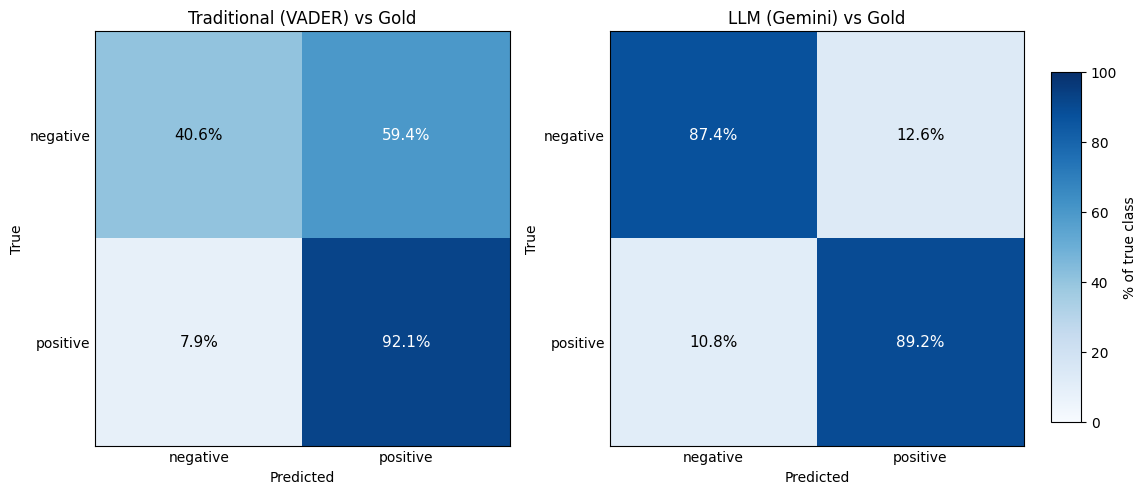

In [81]:
# Percentage-wise confusion matrices (row-normalized: % of each true class predicted as each label)
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

try:
    def pct_cm(cm):
        row_sums = cm.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        return (100 * cm / row_sums).round(1)

    cm_trad = confusion_matrix(gold, trad_labels, labels=labels_cls)
    cm_llm = confusion_matrix(gold, llm_labels, labels=labels_cls)

    pct_trad = pct_cm(cm_trad)
    pct_llm = pct_cm(cm_llm)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, pct, title in zip(axes, [pct_trad, pct_llm], ["Traditional (VADER) vs Gold", "LLM (Gemini) vs Gold"]):
        im = ax.imshow(pct, cmap="Blues", vmin=0, vmax=100)
        ax.set_xticks(range(len(labels_cls)))
        ax.set_yticks(range(len(labels_cls)))
        ax.set_xticklabels(labels_cls)
        ax.set_yticklabels(labels_cls)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        ax.set_title(title, fontsize=12)
        # Set a white background on the axes to prevent overlap with colorbar or other axes.
        ax.set_facecolor('white')
        # Write percent value in center, maximize legibility
        for i in range(len(labels_cls)):
            for j in range(len(labels_cls)):
                color = "black" if pct[i, j] < 50 else "white"
                ax.text(j, i, f"{pct[i, j]:.1f}%", ha="center", va="center", color=color, fontsize=11)
        # Minor ticks off for a cleaner look
        ax.tick_params(axis='both', which='both', length=0)
    # Place colorbar on right next to plots, not overlapping
    fig.subplots_adjust(right=0.85, wspace=0.3)
    cbar_ax = fig.add_axes([0.88, 0.15, 0.025, 0.7])
    fig.colorbar(im, cax=cbar_ax, label="% of true class")
    plt.tight_layout(rect=[0, 0, 0.87, 1])
    plt.show()
except NameError:
    print("Run the sentiment accuracy vs ground truth cell first.")

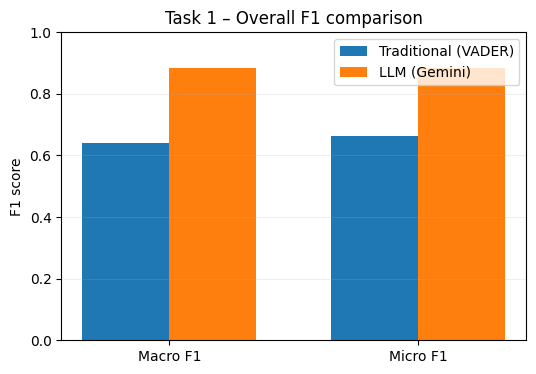

In [82]:
# Task 1 – Overall F1 comparison (macro & micro)
import importlib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

import custom_datasets
importlib.reload(custom_datasets)

gold = [g.strip().lower() for g in custom_datasets.sentiment_ground_truth]
trad = load_csv("results/sentiment_traditional.csv")
llm = load_csv("llm_output/sentiment.csv")

if trad and llm:
    llm_map = {row["id"]: row["label"].strip().lower() for row in llm}
    trad_labels = [row["label"].strip().lower() for row in trad]
    llm_labels = [llm_map.get(row["id"], "").strip().lower() for row in trad]

    n = min(len(gold), len(trad_labels), len(llm_labels))
    gold = gold[:n]
    trad_labels = trad_labels[:n]
    llm_labels = llm_labels[:n]

    labels = sorted(set(gold))

    f1_trad_macro = f1_score(gold, trad_labels, labels=labels, average="macro")
    f1_llm_macro = f1_score(gold, llm_labels, labels=labels, average="macro")
    f1_trad_micro = f1_score(gold, trad_labels, labels=labels, average="micro")
    f1_llm_micro = f1_score(gold, llm_labels, labels=labels, average="micro")

    metrics = ["Macro F1", "Micro F1"]
    trad_vals = [f1_trad_macro, f1_trad_micro]
    llm_vals = [f1_llm_macro, f1_llm_micro]

    x = np.arange(len(metrics))
    width = 0.35

    plt.figure(figsize=(6, 4))
    plt.bar(x - width/2, trad_vals, width, label="Traditional (VADER)")
    plt.bar(x + width/2, llm_vals, width, label="LLM (Gemini)")
    plt.xticks(x, metrics)
    plt.ylabel("F1 score")
    plt.ylim(0, 1.0)
    plt.title("Task 1 – Overall F1 comparison")
    plt.legend()
    plt.grid(axis="y", alpha=0.2)
    plt.show()
else:
    print("Missing sentiment CSVs; run the earlier cells first.")

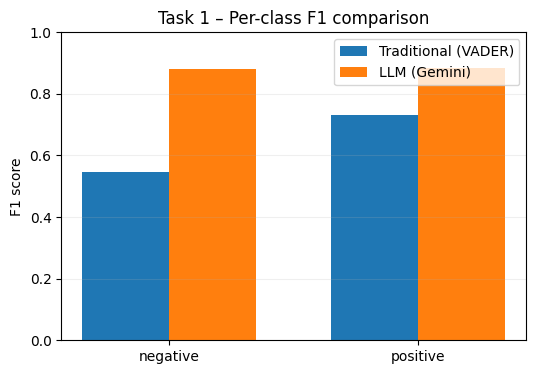

In [83]:
# Task 1 – Per-class F1 comparison
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support

if trad and llm:
    labels = sorted(set(gold))
    _, _, f1_trad_per, _ = precision_recall_fscore_support(
        gold, trad_labels, labels=labels, zero_division=0
    )
    _, _, f1_llm_per, _ = precision_recall_fscore_support(
        gold, llm_labels, labels=labels, zero_division=0
    )

    x = np.arange(len(labels))
    width = 0.35

    plt.figure(figsize=(6, 4))
    plt.bar(x - width/2, f1_trad_per, width, label="Traditional (VADER)")
    plt.bar(x + width/2, f1_llm_per, width, label="LLM (Gemini)")
    plt.xticks(x, labels)
    plt.ylabel("F1 score")
    plt.ylim(0, 1.0)
    plt.title("Task 1 – Per-class F1 comparison")
    plt.legend()
    plt.grid(axis="y", alpha=0.2)
    plt.show()
else:
    print("Missing sentiment variables; run the F1-overall cell first.")

---
## 2. Named Entity Recognition (NER) Comparison

In [84]:
import custom_datasets
types = []
for ents in custom_datasets.ner_ground_truth:
    if ents and ents.strip().upper() != "NONE":
        for part in ents.split(";"):
            part = part.strip()
            if "(" in part and ")" in part:
                types.append(part[part.rfind("(")+1:part.rfind(")")].strip().upper())
total = len(types)
print(f"Task 2 — NER Entity Type Distribution ({total} mentions)")
for label, cnt in sorted(Counter(types).items(), key=lambda x: -x[1]):
    print(f"  {label:>6s}: {cnt:5d}  ({cnt/total*100:.1f}%)")

Task 2 — NER Entity Type Distribution (1639 mentions)
     LOC:   491  (30.0%)
     ORG:   471  (28.7%)
     PER:   446  (27.2%)
    MISC:   231  (14.1%)


In [85]:
def normalize_entities(entities_str):
    """Normalize entities string into a set of (text_lower, type_upper) tuples."""
    entities = set()
    if not entities_str or entities_str.strip().upper() == "NONE":
        return entities
    for part in entities_str.split(";"):
        part = part.strip()
        if "(" in part and ")" in part:
            name = part[:part.rfind("(")].strip().lower()
            etype = part[part.rfind("(") + 1:part.rfind(")")].strip().upper()
            entities.add((name, etype))
    return entities

trad = load_csv("results/ner_traditional.csv")
llm = load_csv("llm_output/ner.csv")

if trad and llm:
    llm_map = {row["id"]: row["entities"] for row in llm}

    rows = []
    total_trad_ents = 0
    total_llm_ents = 0
    total_overlap = 0
    name_overlap = 0

    for row in trad:
        tid = row["id"]
        t_ents = normalize_entities(row["entities"])
        l_ents = normalize_entities(llm_map.get(tid, ""))

        t_names = {name for name, _ in t_ents}
        l_names = {name for name, _ in l_ents}

        overlap = t_ents & l_ents
        n_overlap = t_names & l_names

        total_trad_ents += len(t_ents)
        total_llm_ents += len(l_ents)
        total_overlap += len(overlap)
        name_overlap += len(n_overlap)

        rows.append({
            "ID": tid,
            "Text": row["text"][:45] + "...",
            "Traditional (spaCy)": row["entities"],
            "LLM (Gemini)": llm_map.get(tid, "N/A"),
            "Exact Match": f"{len(overlap)}/{max(len(t_ents), len(l_ents))}"
        })

    df_ner = pd.DataFrame(rows)
    denom = max(total_trad_ents, total_llm_ents) or 1
    exact_pct = accuracy(total_overlap, denom)
    name_pct = accuracy(name_overlap, denom)
    print(f"Entity exact match (name+type): {total_overlap}/{denom} ({exact_pct}%)")
    print(f"Entity name-only match:         {name_overlap}/{denom} ({name_pct}%)\n")
    display(df_ner.head(20) if len(df_ner) > 20 else df_ner)
    if len(df_ner) > 20:
        print(f"... ({len(df_ner)} rows total)")
else:
    print("Skipping — missing file(s)")

Entity exact match (name+type): 932/2422 (38.5%)
Entity name-only match:         1149/2422 (47.4%)



,ID,Text,Traditional (spaCy),LLM (Gemini),Exact Match
0,1,Medicaid would be at risk of being taken away...,Medicaid (ORG),Medicaid (MISC),0/1
1,2,BUDAPEST 1996-08-26...,1996-08-26 (MISC),BUDAPEST (LOC),0/1
2,3,Result : England won by five wickets ....,England (LOC); five (MISC),England (LOC),1/2
3,4,The fifth- seeded Majoli joined Anke Huber ( ...,Majoli (LOC); Anke Huber (PER); 5 (MISC); Magd...,Majoli (PER); Anke Huber (PER); Magdalena Male...,2/5
4,5,"DBRS confirms Power Corp , Power Financial ra...",DBRS confirms Power Corp (ORG); Power Financia...,DBRS (ORG); Power Corp (ORG); Power Financial ...,1/3
5,6,+5 Sigeki Maruyama ( Japan ) through 17...,Japan (LOC); 17 (MISC),Sigeki Maruyama (PER); Japan (LOC),1/2
6,7,Books close September 23-27...,September 23-27 (MISC),NONE,0/1
7,8,They finally went ahead with an escort from t...,NONE,ULIMO-J (ORG),0/1
8,9,The government had been threatening to fire t...,Tuesday (MISC),NONE,0/1
9,10,Australia foreign minister arrives in China ....,Australia (LOC); China (LOC),Australia (LOC); China (LOC),2/2


... (1000 rows total)


### NER accuracy vs ground truth (CoNLL-2003)

This cell uses `ner_ground_truth` from CoNLL-2003 to compute entity-level precision, recall, and F1 for Traditional (spaCy) and LLM (Gemini). Entity types are normalized (e.g. PERSON/PER, GPE→LOC) for comparison.

In [86]:
# NER vs gold: load data (same as previous cell if you ran it; otherwise load here)
import importlib
import custom_datasets
importlib.reload(custom_datasets)
ner_gold_raw = list(custom_datasets.ner_ground_truth)

trad_ner = load_csv("results/ner_traditional.csv")
llm_ner = load_csv("llm_output/ner.csv")

# Normalize entity type for comparison (CoNLL: PER, ORG, LOC, MISC; spaCy: PERSON, ORG, GPE, LOC; LLM: PERSON, ORG, GPE, etc.)
def norm_type(t):
    t = (t or "").strip().upper()
    if t in ("PERSON", "PER"):
        return "PER"
    if t in ("ORG",):
        return "ORG"
    if t in ("LOC", "GPE", "FAC", "LOCATION"):
        return "LOC"
    return "MISC"  # MISC and anything else

def normalize_entities_for_gold(entities_str, type_norm=True):
    """Return set of (text_lower, type_normalized) tuples."""
    entities = set()
    if not entities_str or entities_str.strip().upper() == "NONE":
        return entities
    for part in entities_str.split(";"):
        part = part.strip()
        if "(" in part and ")" in part:
            name = part[:part.rfind("(")].strip().lower()
            etype = part[part.rfind("(") + 1:part.rfind(")")].strip().upper()
            if type_norm:
                etype = norm_type(etype)
            entities.add((name, etype))
    return entities

if trad_ner and ner_gold_raw:
    n_ner = min(len(ner_gold_raw), len(trad_ner))
    if n_ner < len(ner_gold_raw) or n_ner < len(trad_ner):
        print(f"Note: Using first {n_ner} rows (gold={len(ner_gold_raw)}, trad={len(trad_ner)}).\n")
    gold_ents_list = [normalize_entities_for_gold(g) for g in ner_gold_raw[:n_ner]]
    trad_ents_list = [normalize_entities_for_gold(row["entities"]) for row in trad_ner[:n_ner]]
    llm_map_ner = {row["id"]: row["entities"] for row in llm_ner} if llm_ner else {}
    llm_ents_list = [normalize_entities_for_gold(llm_map_ner.get(row["id"], "")) for row in trad_ner[:n_ner]] if llm_map_ner else []

    def entity_prf1(pred_sets, gold_sets):
        tp = fp = fn = 0
        for pred, gold in zip(pred_sets, gold_sets):
            pred, gold = set(pred), set(gold)
            tp += len(pred & gold)
            fp += len(pred - gold)
            fn += len(gold - pred)
        p = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        r = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
        return {"precision": round(p, 4), "recall": round(r, 4), "f1": round(f1, 4), "tp": tp, "fp": fp, "fn": fn}

    res_trad = entity_prf1(trad_ents_list, gold_ents_list)
    print("Traditional (spaCy) vs Gold (entity-level):")
    print(f"  Precision: {res_trad['precision']:.2%}  Recall: {res_trad['recall']:.2%}  F1: {res_trad['f1']:.2%}\n")
    if llm_ents_list:
        res_llm = entity_prf1(llm_ents_list, gold_ents_list)
        print("LLM (Gemini) vs Gold (entity-level):")
        print(f"  Precision: {res_llm['precision']:.2%}  Recall: {res_llm['recall']:.2%}  F1: {res_llm['f1']:.2%}\n")

    # Per-entity-type metrics (PER, ORG, LOC, MISC)
    types_order = ["PER", "ORG", "LOC", "MISC"]
    def prf1_by_type(pred_sets, gold_sets):
        by_type = {t: {"tp": 0, "fp": 0, "fn": 0} for t in types_order}
        for pred, gold in zip(pred_sets, gold_sets):
            for t in types_order:
                pred_t = {(n, typ) for n, typ in pred if typ == t}
                gold_t = {(n, typ) for n, typ in gold if typ == t}
                by_type[t]["tp"] += len(pred_t & gold_t)
                by_type[t]["fp"] += len(pred_t - gold_t)
                by_type[t]["fn"] += len(gold_t - pred_t)
        rows = []
        for t in types_order:
            d = by_type[t]
            tp, fp, fn = d["tp"], d["fp"], d["fn"]
            p = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            r = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
            rows.append({"type": t, "precision": round(p, 4), "recall": round(r, 4), "f1": round(f1, 4)})
        return pd.DataFrame(rows)

    print("Per-entity-type (Traditional vs Gold):")
    display(prf1_by_type(trad_ents_list, gold_ents_list))
    if llm_ents_list:
        print("Per-entity-type (LLM vs Gold):")
        display(prf1_by_type(llm_ents_list, gold_ents_list))

    # Confusion matrices (entity-type): rows = gold type, cols = predicted type (only entities with matching span)
    def entity_type_confusion_matrix(gold_sets, pred_sets, labels):
        cm = np.zeros((len(labels), len(labels)))
        label_idx = {t: i for i, t in enumerate(labels)}
        for gold_set, pred_set in zip(gold_sets, pred_sets):
            gold_set, pred_set = set(gold_set), set(pred_set)
            pred_by_name = {}  # name -> pred_type (one per name if multiple we take last)
            for (n, t) in pred_set:
                pred_by_name[n] = t
            for (name, gtype) in gold_set:
                if name in pred_by_name:
                    ptype = pred_by_name[name]
                    i, j = label_idx.get(gtype, 0), label_idx.get(ptype, 0)
                    cm[i, j] += 1
        return cm

    import numpy as np
    types_order = ["PER", "ORG", "LOC", "MISC"]
    cm_trad_ner = entity_type_confusion_matrix(gold_ents_list, trad_ents_list, types_order)
    print("Confusion matrix — Traditional (spaCy) vs Gold (entity type, span-matched only):")
    display(pd.DataFrame(cm_trad_ner.astype(int), index=types_order, columns=types_order))
    if llm_ents_list:
        cm_llm_ner = entity_type_confusion_matrix(gold_ents_list, llm_ents_list, types_order)
        print("Confusion matrix — LLM (Gemini) vs Gold (entity type, span-matched only):")
        display(pd.DataFrame(cm_llm_ner.astype(int), index=types_order, columns=types_order))

    # Sample table: first 10 rows with Text, Gold, Traditional, LLM
    sample = 10
    df_ner_gold = pd.DataFrame({
        "ID": list(range(1, sample + 1)),
        "Text": [trad_ner[i]["text"][:60] + "..." for i in range(sample)],
        "Gold": [ner_gold_raw[i] for i in range(sample)],
        "Traditional (spaCy)": [trad_ner[i]["entities"] for i in range(sample)],
        "LLM (Gemini)": [llm_map_ner.get(trad_ner[i]["id"], "N/A") for i in range(sample)] if llm_map_ner else ["N/A"] * sample,
    })
    display(df_ner_gold)
else:
    print("Run traditional_nlp.py and ensure results/ner_traditional.csv exists. For LLM metrics, add llm_output/ner_llm.csv.")

Traditional (spaCy) vs Gold (entity-level):
  Precision: 37.94%  Recall: 56.83%  F1: 45.51%

LLM (Gemini) vs Gold (entity-level):
  Precision: 92.79%  Recall: 94.68%  F1: 93.73%

Per-entity-type (Traditional vs Gold):


,type,precision,recall,f1
0,PER,0.7132,0.6539,0.6823
1,ORG,0.4215,0.3269,0.3682
2,LOC,0.7901,0.7292,0.7584
3,MISC,0.1035,0.5580,0.1746


Per-entity-type (LLM vs Gold):


,type,precision,recall,f1
0,PER,0.9955,0.9955,0.9955
1,ORG,0.8956,0.9530,0.9234
2,LOC,0.9458,0.9458,0.9458
3,MISC,0.8282,0.8393,0.8337


Confusion matrix — Traditional (spaCy) vs Gold (entity type, span-matched only):


,PER,ORG,LOC,MISC
PER,291,43,11,5
ORG,34,153,37,8
LOC,17,26,350,6
MISC,4,25,6,125


Confusion matrix — LLM (Gemini) vs Gold (entity type, span-matched only):


,PER,ORG,LOC,MISC
PER,443,0,1,0
ORG,0,446,2,7
LOC,0,13,453,3
MISC,1,3,2,188


,ID,Text,Gold,Traditional (spaCy),LLM (Gemini)
0,1,Medicaid would be at risk of being taken away ...,Medicaid (MISC),Medicaid (ORG),Medicaid (MISC)
1,2,BUDAPEST 1996-08-26...,BUDAPEST (LOC),1996-08-26 (MISC),BUDAPEST (LOC)
2,3,Result : England won by five wickets ....,England (LOC),England (LOC); five (MISC),England (LOC)
3,4,The fifth- seeded Majoli joined Anke Huber ( 5...,Majoli (PER); Anke Huber (PER); Magdalena Male...,Majoli (LOC); Anke Huber (PER); 5 (MISC); Magd...,Majoli (PER); Anke Huber (PER); Magdalena Male...
4,5,"DBRS confirms Power Corp , Power Financial rat...",DBRS (ORG); Power Corp (ORG); Power (ORG),DBRS confirms Power Corp (ORG); Power Financia...,DBRS (ORG); Power Corp (ORG); Power Financial ...
5,6,+5 Sigeki Maruyama ( Japan ) through 17...,Sigeki Maruyama (PER); Japan (LOC),Japan (LOC); 17 (MISC),Sigeki Maruyama (PER); Japan (LOC)
6,7,Books close September 23-27...,NONE,September 23-27 (MISC),NONE
7,8,They finally went ahead with an escort from th...,ULIMO-J (ORG),NONE,ULIMO-J (ORG)
8,9,The government had been threatening to fire th...,NONE,Tuesday (MISC),NONE
9,10,Australia foreign minister arrives in China ....,Australia (LOC); China (LOC),Australia (LOC); China (LOC),Australia (LOC); China (LOC)


C:\Users\skc7\AppData\Local\Temp\ipykernel_22092\356278253.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.87, 1])


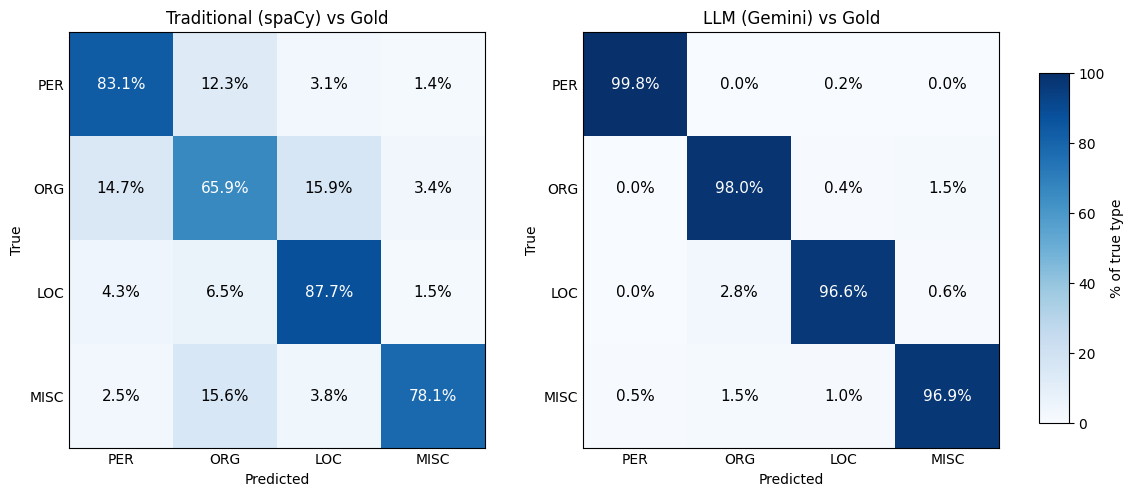

In [87]:
# NER: Percentage-wise confusion matrices (row-normalized: % of each gold type predicted as each type)
import matplotlib.pyplot as plt
import numpy as np

try:
    types_order = ["PER", "ORG", "LOC", "MISC"]
    def pct_cm(cm):
        row_sums = cm.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        return (100 * cm / row_sums).round(1)

    pct_trad_ner = pct_cm(cm_trad_ner)
    pct_llm_ner = pct_cm(cm_llm_ner) if llm_ents_list else None

    n_plots = 2 if pct_llm_ner is not None else 1
    fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))
    if n_plots == 1:
        axes = [axes]
    for ax, pct, title in zip(axes, [pct_trad_ner, pct_llm_ner], ["Traditional (spaCy) vs Gold", "LLM (Gemini) vs Gold"]):
        if pct is None:
            continue
        im = ax.imshow(pct, cmap="Blues", vmin=0, vmax=100)
        ax.set_xticks(range(len(types_order)))
        ax.set_yticks(range(len(types_order)))
        ax.set_xticklabels(types_order)
        ax.set_yticklabels(types_order)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        ax.set_title(title, fontsize=12)
        ax.set_facecolor("white")
        for i in range(len(types_order)):
            for j in range(len(types_order)):
                color = "black" if pct[i, j] < 50 else "white"
                ax.text(j, i, f"{pct[i, j]:.1f}%", ha="center", va="center", color=color, fontsize=11)
        ax.tick_params(axis="both", which="both", length=0)
    fig.subplots_adjust(right=0.85, wspace=0.3)
    cbar_ax = fig.add_axes([0.88, 0.15, 0.025, 0.7])
    fig.colorbar(im, cax=cbar_ax, label="% of true type")
    plt.tight_layout(rect=[0, 0, 0.87, 1])
    plt.show()
except NameError:
    print("Run the NER accuracy vs ground truth cell first.")

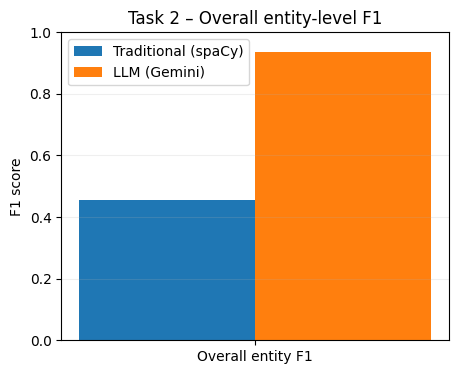

In [88]:
# Task 2 – Overall entity-level F1 comparison
import matplotlib.pyplot as plt
import numpy as np

if "gold_ents_list" in globals() and "trad_ents_list" in globals():
    # entity_prf1 and res_trad / res_llm were defined in the NER comparison cell
    overall_trad_f1 = res_trad["f1"] if "res_trad" in globals() else 0.0
    overall_llm_f1 = res_llm["f1"] if "res_llm" in globals() else 0.0

    metrics = ["Overall entity F1"]
    trad_vals = [overall_trad_f1]
    llm_vals = [overall_llm_f1]

    x = np.arange(len(metrics))
    width = 0.35

    plt.figure(figsize=(5, 4))
    plt.bar(x - width/2, trad_vals, width, label="Traditional (spaCy)")
    plt.bar(x + width/2, llm_vals, width, label="LLM (Gemini)")
    plt.xticks(x, metrics)
    plt.ylabel("F1 score")
    plt.ylim(0, 1.0)
    plt.title("Task 2 – Overall entity-level F1")
    plt.legend()
    plt.grid(axis="y", alpha=0.2)
    plt.show()
else:
    print("Run the main NER comparison cell first.")

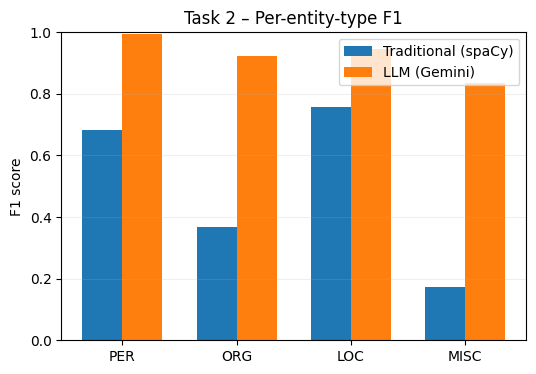

In [89]:
# Task 2 – Per-entity-type F1 comparison (PER / ORG / LOC / MISC)
import matplotlib.pyplot as plt
import numpy as np

if "gold_ents_list" in globals() and "trad_ents_list" in globals():
    types_order = ["PER", "ORG", "LOC", "MISC"]

    df_trad = prf1_by_type(trad_ents_list, gold_ents_list)
    if "llm_ents_list" in globals() and llm_ents_list:
        df_llm = prf1_by_type(llm_ents_list, gold_ents_list)
    else:
        df_llm = None

    trad_f1 = [df_trad.loc[df_trad["type"] == t, "f1"].values[0] for t in types_order]
    llm_f1 = [df_llm.loc[df_llm["type"] == t, "f1"].values[0] for t in types_order] if df_llm is not None else [0]*len(types_order)

    x = np.arange(len(types_order))
    width = 0.35

    plt.figure(figsize=(6, 4))
    plt.bar(x - width/2, trad_f1, width, label="Traditional (spaCy)")
    plt.bar(x + width/2, llm_f1, width, label="LLM (Gemini)")
    plt.xticks(x, types_order)
    plt.ylabel("F1 score")
    plt.ylim(0, 1.0)
    plt.title("Task 2 – Per-entity-type F1")
    plt.legend()
    plt.grid(axis="y", alpha=0.2)
    plt.show()
else:
    print("Run the main NER comparison cell first.")

---
## 3. POS Tagging Comparison

In [90]:
import custom_datasets
tags = []
for tags_str in custom_datasets.pos_ground_truth:
    if tags_str:
        tags.extend([t.strip() for t in tags_str.split(",")])
total = len(tags)
print(f"Task 3 — POS Tag Distribution ({total} tokens)")
for label, cnt in sorted(Counter(tags).items(), key=lambda x: -x[1]):
    print(f"  {label:>6s}: {cnt:5d}  ({cnt/total*100:.1f}%)")

Task 3 — POS Tag Distribution (1993 tokens)
       /:   454  (22.8%)
        :    10  (0.5%)
  000/CD:     6  (0.3%)
  000/CD ./.:     4  (0.2%)
  000/CD 14:     4  (0.2%)
     775:     4  (0.2%)
  police/NNS said/VBD ./.:     3  (0.2%)
  won/VBD:     3  (0.2%)
  drawn/VBN:     3  (0.2%)
  lost/VBD:     3  (0.2%)
  CENTRAL/NNP DIVISION/NNP:     3  (0.2%)
  6-3/CD:     2  (0.1%)
  1996/CD )/):     2  (0.1%)
  --/: Dimitris/NNP Kontogiannis/NNP:     2  (0.1%)
  Athens/NNP Newsroom/NNP +301/NNP 3311812-4/CD:     2  (0.1%)
  SPA-FRANCORCHAMPS/JJ:     2  (0.1%)
  WESTERN/NNP DIVISION/NNP:     2  (0.1%)
   */SYM:     2  (0.1%)
  South/NNP Sydney/NNP 21/CD 5/CD 1/CD 15/CD 304/CD 586/CD 11/CD:     2  (0.1%)
  W/NNP L/NNP PCT/NNP GB/NNP:     2  (0.1%)
  500/CD ./.:     2  (0.1%)
     "/":     2  (0.1%)
  Major/NNP League/NNP Baseball/NNP:     2  (0.1%)
  BONN/NN 1996-08-22/CD:     2  (0.1%)
  UNITED/NNP NATIONS/NNS 1996-08-28/CD:     2  (0.1%)
  number/NN denotes/VBZ seeding/NN )/) :/::     2  

### POS accuracy vs ground truth (CoNLL-2003)

This cell uses `pos_ground_truth` from CoNLL-2003 (Penn Treebank tags) to compute token-level accuracy and confusion matrices for Traditional (NLTK) and LLM (Gemini). Tags are aligned by position (min length) per sentence.

In [91]:
# POS vs gold: load data
import importlib
import numpy as np
import custom_datasets
importlib.reload(custom_datasets)
pos_gold_raw = list(custom_datasets.pos_ground_truth)

trad_pos = load_csv("results/pos_traditional.csv")
llm_pos = load_csv("llm_output/pos.csv")

def parse_pos_tags(pos_str):
    """Parse 'w1/T1 w2/T2 ...' to list of tags (order preserved)."""
    if not pos_str or not pos_str.strip():
        return []
    tags = []
    for pair in pos_str.split():
        if "/" in pair:
            tags.append(pair.rsplit("/", 1)[1])
        else:
            tags.append("")
    return tags

if trad_pos and pos_gold_raw:
    n_pos = min(len(pos_gold_raw), len(trad_pos))
    if n_pos < len(pos_gold_raw) or n_pos < len(trad_pos):
        print(f"Note: Using first {n_pos} rows (gold={len(pos_gold_raw)}, trad={len(trad_pos)}).\n")
    gold_pos_list = [parse_pos_tags(pos_gold_raw[i]) for i in range(n_pos)]
    trad_pos_list = [parse_pos_tags(trad_pos[i]["pos_tags"]) for i in range(n_pos)]
    llm_map_pos = {row["id"]: row["pos_tags"] for row in llm_pos} if llm_pos else {}
    llm_pos_list = [parse_pos_tags(llm_map_pos.get(trad_pos[i]["id"], "")) for i in range(n_pos)] if llm_map_pos else []

    pairs_trad = []
    for i in range(n_pos):
        g, t = gold_pos_list[i], trad_pos_list[i]
        for j in range(min(len(g), len(t))):
            pairs_trad.append((g[j], t[j]))
    correct_trad = sum(1 for g, p in pairs_trad if g == p)
    total_trad = len(pairs_trad)

    print("Traditional (NLTK) vs Gold (token-level):")
    print(f"  Accuracy: {correct_trad}/{total_trad} ({100*correct_trad/total_trad if total_trad else 0:.2f}%)\n")
    if llm_map_pos:
        pairs_llm = []
        for i in range(n_pos):
            g, t = gold_pos_list[i], llm_pos_list[i]
            for j in range(min(len(g), len(t))):
                pairs_llm.append((g[j], t[j]))
        correct_llm = sum(1 for g, p in pairs_llm if g == p)
        total_llm = len(pairs_llm)
        print("LLM (Gemini) vs Gold (token-level):")
        print(f"  Accuracy: {correct_llm}/{total_llm} ({100*correct_llm/total_llm if total_llm else 0:.2f}%)\n")

    # Confusion matrix: all (gold_tag, pred_tag) pairs; use sorted unique tags
    all_gold_tags = sorted(set(g for g, p in pairs_trad))
    all_pred_tags = sorted(set(p for g, p in pairs_trad))
    tag_set = sorted(set(all_gold_tags) | set(all_pred_tags))
    tag_idx = {t: i for i, t in enumerate(tag_set)}
    cm_trad_pos = np.zeros((len(tag_set), len(tag_set)))
    for g, p in pairs_trad:
        i, j = tag_idx.get(g, 0), tag_idx.get(p, 0)
        cm_trad_pos[i, j] += 1
    print("Confusion matrix — Traditional (NLTK) vs Gold (top 12 tags by gold frequency):")
    gold_freq = sorted([(t, sum(1 for g, _ in pairs_trad if g == t)) for t in tag_set], key=lambda x: -x[1])
    top_tags = [t for t, _ in gold_freq[:12]]
    idx_top = {t: i for i, t in enumerate(top_tags)}
    cm_top = np.zeros((len(top_tags), len(top_tags)))
    for g, p in pairs_trad:
        if g in idx_top and p in idx_top:
            cm_top[idx_top[g], idx_top[p]] += 1
    display(pd.DataFrame(cm_top.astype(int), index=top_tags, columns=top_tags))
    if llm_map_pos:
        cm_llm_pos = np.zeros((len(tag_set), len(tag_set)))
        for g, p in pairs_llm:
            i, j = tag_idx.get(g, 0), tag_idx.get(p, 0)
            cm_llm_pos[i, j] += 1
        print("Confusion matrix — LLM (Gemini) vs Gold (top 12 tags):")
        cm_top_llm = np.zeros((len(top_tags), len(top_tags)))
        for g, p in pairs_llm:
            if g in idx_top and p in idx_top:
                cm_top_llm[idx_top[g], idx_top[p]] += 1
        display(pd.DataFrame(cm_top_llm.astype(int), index=top_tags, columns=top_tags))

    # Sample table
    sample = 5
    df_pos_gold = pd.DataFrame({
        "ID": list(range(1, sample + 1)),
        "Text": [trad_pos[i]["text"][:50] + "..." for i in range(sample)],
        "Gold (excerpt)": [pos_gold_raw[i][:60] + "..." for i in range(sample)],
        "Traditional (excerpt)": [trad_pos[i]["pos_tags"][:60] + "..." for i in range(sample)],
        "LLM (excerpt)": [llm_map_pos.get(trad_pos[i]["id"], "N/A")[:60] + "..." for i in range(sample)] if llm_map_pos else ["N/A"] * sample,
    })
    display(df_pos_gold)
else:
    print("Run traditional_nlp.py --tasks pos and ensure results/pos_traditional.csv exists.")

Traditional (NLTK) vs Gold (token-level):
  Accuracy: 12377/14036 (88.18%)

LLM (Gemini) vs Gold (token-level):
  Accuracy: 12453/13944 (89.31%)

Confusion matrix — Traditional (NLTK) vs Gold (top 12 tags by gold frequency):


,NNP,NN,CD,IN,DT,JJ,NNS,VBD,.,",",VB,VBN
NNP,2181,43,14,6,1,52,17,3,42,0,4,1
NN,94,1432,6,5,5,40,21,4,0,0,14,2
CD,19,18,1173,1,0,120,10,5,0,0,3,0
IN,15,4,1,1246,3,0,5,0,0,0,2,0
DT,1,0,0,8,907,0,0,1,0,0,1,0
JJ,69,47,13,1,0,555,3,7,0,0,6,6
NNS,51,15,6,1,2,2,633,1,0,0,1,0
VBD,3,4,0,0,0,1,0,566,0,0,0,26
.,3,1,1,0,0,0,2,0,516,0,0,0
",",3,1,0,0,0,0,0,0,0,450,0,0


Confusion matrix — LLM (Gemini) vs Gold (top 12 tags):


,NNP,NN,CD,IN,DT,JJ,NNS,VBD,.,",",VB,VBN
NNP,2207,81,25,19,2,59,14,1,1,0,0,1
NN,65,1482,7,3,3,24,22,3,0,0,12,2
CD,2,3,1310,1,0,13,2,0,0,0,0,0
IN,6,1,0,1261,2,1,0,0,0,0,0,0
DT,1,2,0,2,909,0,0,0,0,0,0,0
JJ,32,41,11,1,0,604,1,6,0,0,1,10
NNS,25,8,1,0,0,2,670,0,0,0,0,0
VBD,0,1,0,0,0,2,0,564,0,0,0,35
.,1,1,0,0,0,0,0,1,510,0,0,0
",",1,0,0,1,0,0,1,0,0,446,0,0


,ID,Text,Gold (excerpt),Traditional (excerpt),LLM (excerpt)
0,1,Medicaid would be at risk of being taken away ...,Medicaid/NNP would/MD be/VB at/IN risk/NN of/I...,Medicaid/NNP would/MD be/VB at/IN risk/NN of/I...,Medicaid/NNP would/MD be/VB at/IN risk/NN of/I...
1,2,BUDAPEST 1996-08-26...,BUDAPEST/RB 1996-08-26/CD...,BUDAPEST/IN 1996-08-26/JJ...,BUDAPEST/NNP 1996-08-26/CD...
2,3,Result : England won by five wickets ....,Result/NN :/: England/NNP won/VBD by/IN five/C...,Result/NN :/: England/NNP won/VBD by/IN five/C...,Result/NN :/: England/NNP won/VBD by/IN five/C...
3,4,The fifth- seeded Majoli joined Anke Huber ( 5...,The/DT fifth-/JJ seeded/VBN Majoli/NNP joined/...,The/DT fifth-/NN seeded/VBD Majoli/NNP joined/...,The/DT fifth-/JJ seeded/JJ Majoli/NNP joined/V...
4,5,"DBRS confirms Power Corp , Power Financial rat...","DBRS/NNS confirms/VBZ Power/NNP Corp/NNP ,/, P...","DBRS/NNP confirms/VBZ Power/NNP Corp/NNP ,/, P...","DBRS/NNP confirms/VBZ Power/NNP Corp/NNP ,/, P..."


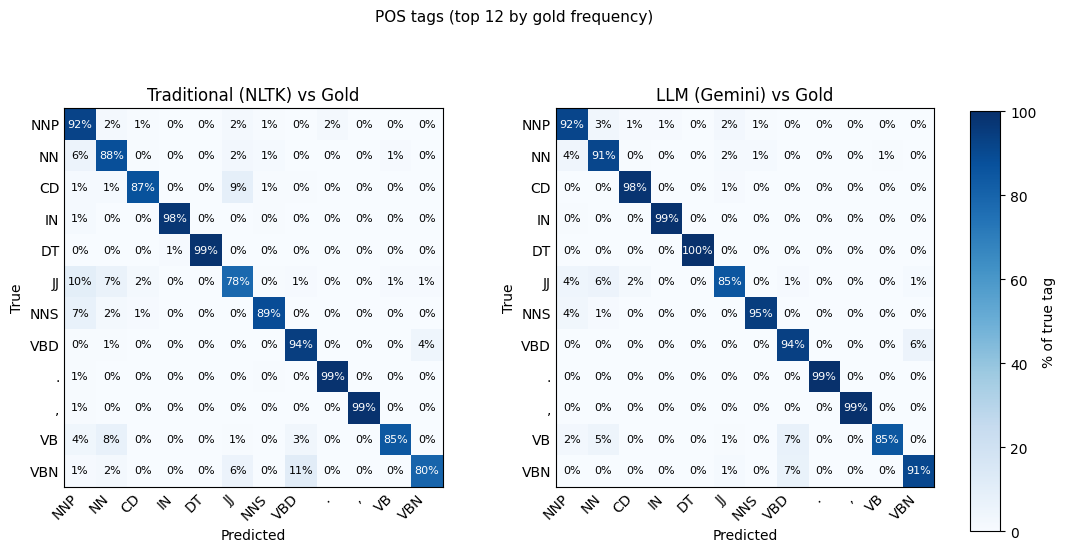

In [92]:
# POS: Percentage-wise confusion matrices (top 12 tags, row-normalized)
import matplotlib.pyplot as plt
import numpy as np

try:
    def pct_cm(cm):
        row_sums = cm.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        return (100 * cm / row_sums).round(1)

    try:
        cm_list = [cm_top, cm_top_llm]
        title_list = ["Traditional (NLTK) vs Gold", "LLM (Gemini) vs Gold"]
    except NameError:
        cm_list = [cm_top]
        title_list = ["Traditional (NLTK) vs Gold"]
    n_plots = len(cm_list)
    fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 6))
    if n_plots == 1:
        axes = [axes]
    for ax, cm, title in zip(axes, cm_list, title_list):
        pct = pct_cm(cm)
        im = ax.imshow(pct, cmap="Blues", vmin=0, vmax=100)
        ax.set_xticks(range(len(top_tags)))
        ax.set_yticks(range(len(top_tags)))
        ax.set_xticklabels(top_tags, rotation=45, ha="right")
        ax.set_yticklabels(top_tags)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        ax.set_title(title, fontsize=12)
        ax.set_facecolor("white")
        for i in range(len(top_tags)):
            for j in range(len(top_tags)):
                color = "black" if pct[i, j] < 50 else "white"
                ax.text(j, i, f"{pct[i, j]:.0f}%", ha="center", va="center", color=color, fontsize=8)
        ax.tick_params(axis="both", which="both", length=0)
    fig.subplots_adjust(right=0.85, wspace=0.3, bottom=0.2)
    cbar_ax = fig.add_axes([0.88, 0.15, 0.025, 0.7])
    fig.colorbar(im, cax=cbar_ax, label="% of true tag")
    plt.suptitle("POS tags (top 12 by gold frequency)", fontsize=11, y=1.02)
    plt.show()
except NameError:
    print("Run the POS accuracy vs ground truth cell first.")

In [93]:
trad = load_csv("results/pos_traditional.csv")
llm = load_csv("llm_output/pos.csv")

if trad and llm:
    llm_map = {row["id"]: row["pos_tags"] for row in llm}

    rows = []
    total_tokens = 0
    total_match = 0

    for row in trad:
        tid = row["id"]
        t_tags = row["pos_tags"].split()
        l_tags = llm_map.get(tid, "").split()

        # Build word -> tag dicts
        t_dict = {}
        for pair in t_tags:
            if "/" in pair:
                parts = pair.rsplit("/", 1)
                t_dict[parts[0].lower()] = parts[1]

        l_dict = {}
        for pair in l_tags:
            if "/" in pair:
                parts = pair.rsplit("/", 1)
                l_dict[parts[0].lower()] = parts[1]

        matches = 0
        compared = 0
        for word, tag in t_dict.items():
            if word in l_dict:
                compared += 1
                if l_dict[word] == tag:
                    matches += 1

        total_tokens += compared
        total_match += matches

        pct = accuracy(matches, compared) if compared > 0 else 0
        rows.append({
            "ID": tid,
            "Text": row["text"][:45] + "...",
            "Traditional (NLTK)": row["pos_tags"][:50] + "...",
            "LLM (Gemini)": llm_map.get(tid, "")[:50] + "...",
            "Token Match": f"{matches}/{compared} ({pct}%)"
        })

    df_pos = pd.DataFrame(rows)
    overall = accuracy(total_match, total_tokens)
    print(f"Overall token-level agreement: {total_match}/{total_tokens} ({overall}%)\n")
    display(df_pos)
else:
    print("Skipping — missing file(s)")

Overall token-level agreement: 11283/12610 (89.5%)



,ID,Text,Traditional (NLTK),LLM (Gemini),Token Match
0,1,Medicaid would be at risk of being taken away...,Medicaid/NNP would/MD be/VB at/IN risk/NN of/I...,Medicaid/NNP would/MD be/VB at/IN risk/NN of/I...,13/13 (100.0%)
1,2,BUDAPEST 1996-08-26...,BUDAPEST/IN 1996-08-26/JJ...,BUDAPEST/NNP 1996-08-26/CD...,0/2 (0.0%)
2,3,Result : England won by five wickets ....,Result/NN :/: England/NNP won/VBD by/IN five/C...,Result/NN :/: England/NNP won/VBD by/IN five/C...,8/8 (100.0%)
3,4,The fifth- seeded Majoli joined Anke Huber ( ...,The/DT fifth-/NN seeded/VBD Majoli/NNP joined/...,The/DT fifth-/JJ seeded/JJ Majoli/NNP joined/V...,13/17 (76.5%)
4,5,"DBRS confirms Power Corp , Power Financial ra...","DBRS/NNP confirms/VBZ Power/NNP Corp/NNP ,/, P...","DBRS/NNP confirms/VBZ Power/NNP Corp/NNP ,/, P...",8/8 (100.0%)
...,...,...,...,...,...
995,996,Neagle ( 14-6 ) beat the Braves for the third...,Neagle/NNP (/( 14-6/JJ )/) beat/VBP the/DT Bra...,Neagle/NNP (/-LRB- 14-6/CD )/-RRB- beat/VBD th...,18/23 (78.3%)
996,997,Officials said lack of funding had delayed th...,Officials/NNS said/VBD lack/NN of/IN funding/N...,Officials/NNS said/VBD lack/NN of/IN funding/N...,10/10 (100.0%)
997,998,Quarter ended June 30 Six Months ended June 3...,Quarter/NN ended/VBD June/NNP 30/CD Six/NNP Mo...,Quarter/NN ended/VBN June/NNP 30/CD Six/CD Mon...,3/6 (50.0%)
998,999,3-1 ....,3-1/CD ./....,3-1/CD ./....,2/2 (100.0%)


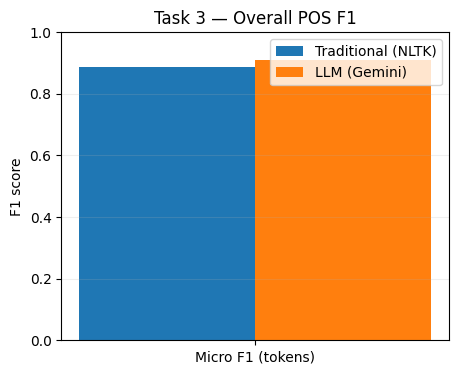

In [105]:
# Task 3 – Overall POS F1 comparison (token-level)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

trad_pos = load_csv("results/pos_traditional.csv")
llm_pos = load_csv("llm_output/pos.csv")

if trad_pos and llm_pos:
    # gold POS tags from custom_datasets
    import importlib, custom_datasets
    importlib.reload(custom_datasets)
    gold_strs = list(custom_datasets.pos_ground_truth)

    def parse_pos_tags(pos_str):
        if not pos_str or not pos_str.strip():
            return []
        tags = []
        for pair in pos_str.split():
            if "/" in pair:
                tags.append(pair.rsplit("/", 1)[1])
            else:
                tags.append("")
        return tags

    gold_list = [parse_pos_tags(s) for s in gold_strs]
    trad_list = [parse_pos_tags(r["pos_tags"]) for r in trad_pos]
    llm_map = {r["id"]: r["pos_tags"] for r in llm_pos}
    llm_list = [parse_pos_tags(llm_map.get(r["id"], "")) for r in trad_pos]

    # Flatten aligned pairs
    pairs_trad = []
    pairs_llm = []
    for g, t, l in zip(gold_list, trad_list, llm_list):
        m = min(len(g), len(t), len(l))
        pairs_trad.extend((g[i], t[i]) for i in range(m))
        pairs_llm.extend((g[i], l[i]) for i in range(m))

    gold_flat = [g for g, _ in pairs_trad]
    trad_flat = [p for _, p in pairs_trad]
    llm_flat = [p for _, p in pairs_llm]

    labels = sorted(set(gold_flat))

    f1_trad = f1_score(gold_flat, trad_flat, labels=labels, average="micro")
    f1_llm = f1_score(gold_flat, llm_flat, labels=labels, average="micro")

    metrics = ["Micro F1 (tokens)"]
    trad_vals = [f1_trad]
    llm_vals = [f1_llm]

    x = np.arange(len(metrics))
    width = 0.35

    plt.figure(figsize=(5, 4))
    plt.bar(x - width/2, trad_vals, width, label="Traditional (NLTK)")
    plt.bar(x + width/2, llm_vals, width, label="LLM (Gemini)")
    plt.xticks(x, metrics)
    plt.ylabel("F1 score")
    plt.ylim(0, 1.0)
    plt.title("Task 3 — Overall POS F1")
    plt.legend()
    plt.grid(axis="y", alpha=0.2)
    plt.show()
else:
    print("Missing POS CSVs; run traditional_nlp.py for POS and export LLM results.")

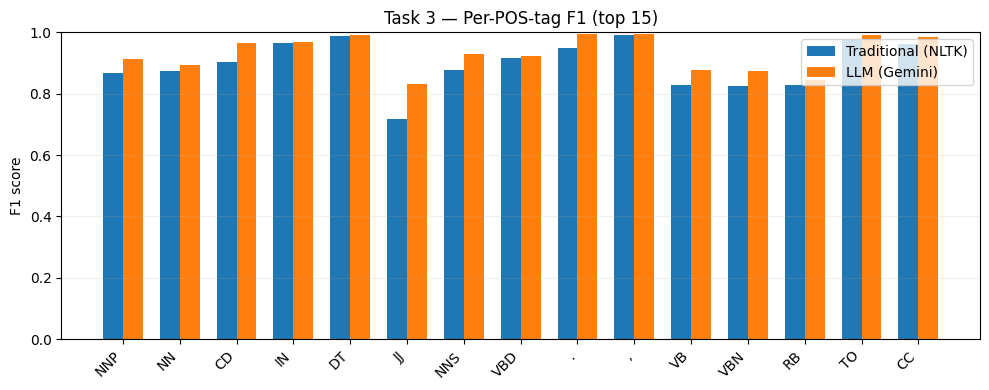

In [106]:
# Task 3 – Per-POS-tag F1 comparison (top 15 tags)
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import precision_recall_fscore_support

if trad_pos and llm_pos:
    # gold_flat, trad_flat, llm_flat from previous cell
    tag_counts = Counter(gold_flat)
    top_tags = [t for t, _ in tag_counts.most_common(15)]

    _, _, f1_trad_per, _ = precision_recall_fscore_support(
        gold_flat, trad_flat, labels=top_tags, zero_division=0
    )
    _, _, f1_llm_per, _ = precision_recall_fscore_support(
        gold_flat, llm_flat, labels=top_tags, zero_division=0
    )

    x = np.arange(len(top_tags))
    width = 0.35

    plt.figure(figsize=(10, 4))
    plt.bar(x - width/2, f1_trad_per, width, label="Traditional (NLTK)")
    plt.bar(x + width/2, f1_llm_per, width, label="LLM (Gemini)")
    plt.xticks(x, top_tags, rotation=45, ha="right")
    plt.ylabel("F1 score")
    plt.ylim(0, 1.0)
    plt.title("Task 3 — Per-POS-tag F1 (top 15)")
    plt.legend()
    plt.grid(axis="y", alpha=0.2)
    plt.tight_layout()
    plt.show()
else:
    print("Run the Task 3 overall F1 cell first.")

---
## 4. Topic Modelling Comparison

In [96]:
import custom_datasets
gold = [g.strip() for g in custom_datasets.topic_ground_truth]
total = len(gold)
print(f"Task 4 — Data Distribution ({total} samples)")
for label, cnt in sorted(Counter(gold).items()):
    print(f"  {label:>12s}: {cnt:5d}  ({cnt/total*100:.1f}%)")

Task 4 — Data Distribution (1000 samples)
      Business:   248  (24.8%)
      Sci/Tech:   244  (24.4%)
        Sports:   246  (24.6%)
         World:   262  (26.2%)


In [97]:
trad = load_csv("results/topic_traditional.csv")
llm = load_csv("llm_output/topic.csv")

if trad and llm:
    llm_map = {row["id"]: row["topic"].strip() for row in llm}

    rows = []
    trad_correct = 0
    llm_correct = 0
    agree = 0

    for row in trad:
        tid = row["id"]
        actual = row["actual"].strip()
        # handle both column name variants from traditional_nlp.py
        t_pred = row.get("predicted", row.get("topic", "???")).strip()
        l_pred = llm_map.get(tid, "???").strip()

        t_ok = t_pred.lower() == actual.lower()
        l_ok = l_pred.lower() == actual.lower()

        if t_pred.lower() == l_pred.lower():
            agree += 1
        if t_ok:
            trad_correct += 1
        if l_ok:
            llm_correct += 1

        rows.append({
            "ID": tid,
            "Text": row["text"][:55] + "...",
            "Actual": actual,
            "Traditional (NB)": t_pred,
            "LLM (Gemini)": l_pred,
            "Trad Correct": "Yes" if t_ok else "No",
            "LLM Correct": "Yes" if l_ok else "No",
        })

    df_topic = pd.DataFrame(rows)
    total = len(rows)
    print(f"Traditional accuracy: {trad_correct}/{total} ({accuracy(trad_correct, total)}%)")
    print(f"LLM accuracy:        {llm_correct}/{total} ({accuracy(llm_correct, total)}%)")
    print(f"Both agree:          {agree}/{total} ({accuracy(agree, total)}%)\n")

    # Per-class metrics
    topic_labels = sorted(set(row["actual"].strip() for row in trad))
    t_actual_list = [row["actual"].strip() for row in trad]
    t_pred_list = [row.get("predicted", row.get("topic", "???")).strip() for row in trad]
    l_pred_list = [llm_map.get(row["id"], "???").strip() for row in trad]

    print("Per-class Precision / Recall / F1 — Traditional (NB) vs LLM (Gemini):\n")
    display(classification_report_side_by_side(
        t_actual_list, t_pred_list, l_pred_list, topic_labels,
        trad_name="Traditional (NB)", llm_name="LLM (Gemini)"))
    print()
    display(df_topic)
else:
    print("Skipping — missing file(s)")

Traditional accuracy: 885/1000 (88.5%)
LLM accuracy:        885/1000 (88.5%)
Both agree:          928/1000 (92.8%)

Per-class Precision / Recall / F1 — Traditional (NB) vs LLM (Gemini):



Precision                        Recall               \
Model     Traditional (NB) LLM (Gemini) Traditional (NB) LLM (Gemini)   
Class                                                                   
Accuracy            0.8850       0.8850                                 
Business            0.8398       0.8264           0.8669       0.8831   
Macro Avg           0.8848       0.8853           0.8857       0.8854   
Micro Avg           0.8850       0.8850            0.885        0.885   
Sci/Tech            0.8672       0.8739           0.8566       0.8238   
Sports              0.9302       0.9416           0.9756       0.9837   
World               0.9020       0.8992           0.8435       0.8511   

                  F1-Score                       Support               
Model     Traditional (NB) LLM (Gemini) Traditional (NB) LLM (Gemini)  
Class                                                                  
Accuracy                                            1000         1000  
Business            0.8532       0.8538              248          248  
Macro Avg           0.8848       0.8847             1000         1000  
Micro Avg            0.885        0.885             1000         1000  
Sci/Tech            0.8619       0.8481              244          244  
Sports              0.9524       0.9622              246          246  
World               0.8718       0.8745              262          262

,ID,Text,Actual,Traditional (NB),LLM (Gemini),Trad Correct,LLM Correct
0,1,Gas prices up 5 cents after Hurricane Ivan CAM...,Sci/Tech,Business,Business,No,No
1,2,"With a Rookie Quarterback in the N.F.L., Call ...",Sports,Sports,Sports,Yes,Yes
2,3,Hynix's 3Q Profit More Than Triples (AP) AP - ...,World,Business,Business,No,No
3,4,Toy store profits R back up TOY retailer Toys ...,Business,Business,Business,Yes,Yes
4,5,Challenger disappoints with writedown The Kerr...,Business,Business,Business,Yes,Yes
...,...,...,...,...,...,...,...
995,996,Kidnappers may extend deadline Militants holdi...,World,World,World,Yes,Yes
996,997,Cordero sets new club mark com. Cordero notche...,Sports,Sports,Sports,Yes,Yes
997,998,Medtronic Quarterly Net Up CHICAGO (Reuters) ...,Business,Business,Business,Yes,Yes
998,999,Dow Jones to buy MarketWatch SAN FRANCISCO: Ma...,Business,Business,Business,Yes,Yes


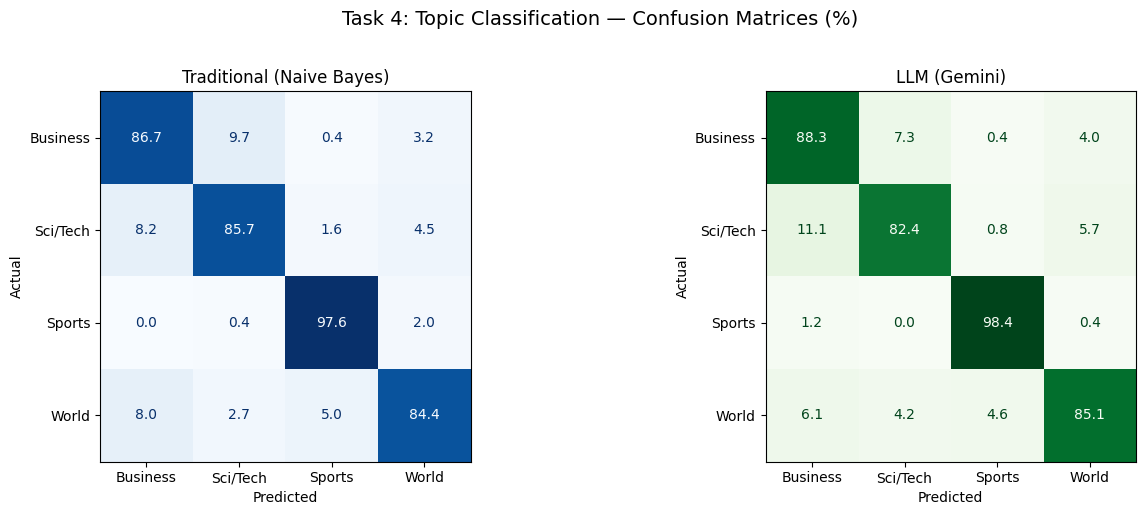

In [98]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

if trad and llm:
    topic_labels = sorted(set(row["actual"].strip() for row in trad))

    t_actual = [row["actual"].strip() for row in trad]
    t_pred = [row.get("predicted", row.get("topic", "???")).strip() for row in trad]
    l_pred = [llm_map.get(row["id"], "???").strip() for row in trad]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Traditional — percentage confusion matrix (row-normalized)
    cm_trad = confusion_matrix(t_actual, t_pred, labels=topic_labels)
    cm_trad_pct = cm_trad.astype(float) / cm_trad.sum(axis=1, keepdims=True) * 100
    disp_trad = ConfusionMatrixDisplay(cm_trad_pct, display_labels=topic_labels)
    disp_trad.plot(ax=axes[0], cmap="Blues", colorbar=False, values_format=".1f")
    axes[0].set_title("Traditional (Naive Bayes)")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")

    # LLM — percentage confusion matrix (row-normalized)
    cm_llm = confusion_matrix(t_actual, l_pred, labels=topic_labels)
    cm_llm_pct = cm_llm.astype(float) / cm_llm.sum(axis=1, keepdims=True) * 100
    disp_llm = ConfusionMatrixDisplay(cm_llm_pct, display_labels=topic_labels)
    disp_llm.plot(ax=axes[1], cmap="Greens", colorbar=False, values_format=".1f")
    axes[1].set_title("LLM (Gemini)")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("Actual")

    plt.suptitle("Task 4: Topic Classification — Confusion Matrices (%)", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping — missing file(s)")

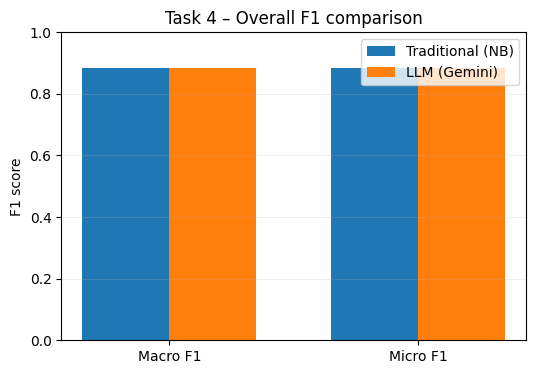

In [99]:
# Task 4 – Overall F1 comparison (macro & micro)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

trad = load_csv("results/topic_traditional.csv")
llm = load_csv("llm_output/topic.csv")

if trad and llm:
    topic_labels = sorted(set(row["actual"].strip() for row in trad))
    gold = [row["actual"].strip() for row in trad]
    trad_pred = [row.get("predicted", row.get("topic", "???")).strip() for row in trad]
    llm_map = {row["id"]: row["topic"].strip() for row in llm}
    llm_pred = [llm_map.get(row["id"], "???").strip() for row in trad]

    n = min(len(gold), len(trad_pred), len(llm_pred))
    gold = gold[:n]
    trad_pred = trad_pred[:n]
    llm_pred = llm_pred[:n]

    f1_trad_macro = f1_score(gold, trad_pred, labels=topic_labels, average="macro")
    f1_llm_macro = f1_score(gold, llm_pred, labels=topic_labels, average="macro")
    f1_trad_micro = f1_score(gold, trad_pred, labels=topic_labels, average="micro")
    f1_llm_micro = f1_score(gold, llm_pred, labels=topic_labels, average="micro")

    metrics = ["Macro F1", "Micro F1"]
    trad_vals = [f1_trad_macro, f1_trad_micro]
    llm_vals = [f1_llm_macro, f1_llm_micro]

    x = np.arange(len(metrics))
    width = 0.35

    plt.figure(figsize=(6, 4))
    plt.bar(x - width/2, trad_vals, width, label="Traditional (NB)")
    plt.bar(x + width/2, llm_vals, width, label="LLM (Gemini)")
    plt.xticks(x, metrics)
    plt.ylabel("F1 score")
    plt.ylim(0, 1.0)
    plt.title("Task 4 – Overall F1 comparison")
    plt.legend()
    plt.grid(axis="y", alpha=0.2)
    plt.show()
else:
    print("Missing topic CSVs; run the earlier topic cells first.")

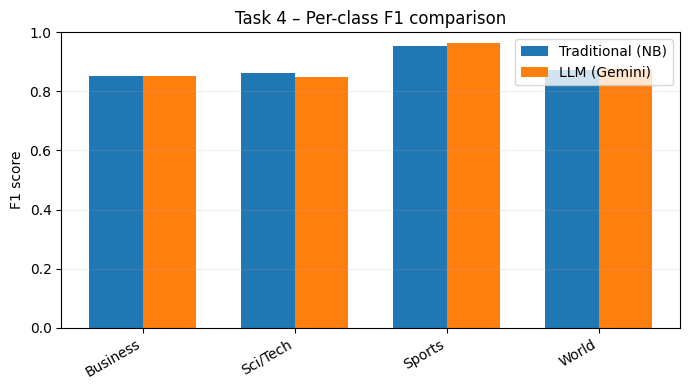

In [100]:
# Task 4 – Per-class F1 comparison
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support

if trad and llm:
    labels = sorted(set(gold))
    _, _, f1_trad_per, _ = precision_recall_fscore_support(
        gold, trad_pred, labels=labels, zero_division=0
    )
    _, _, f1_llm_per, _ = precision_recall_fscore_support(
        gold, llm_pred, labels=labels, zero_division=0
    )

    x = np.arange(len(labels))
    width = 0.35

    plt.figure(figsize=(7, 4))
    plt.bar(x - width/2, f1_trad_per, width, label="Traditional (NB)")
    plt.bar(x + width/2, f1_llm_per, width, label="LLM (Gemini)")
    plt.xticks(x, labels, rotation=30, ha="right")
    plt.ylabel("F1 score")
    plt.ylim(0, 1.0)
    plt.title("Task 4 – Per-class F1 comparison")
    plt.legend()
    plt.grid(axis="y", alpha=0.2)
    plt.tight_layout()
    plt.show()
else:
    print("Missing topic variables; run the Task 4 F1-overall cell first.")

---
## 5. Language Identification Comparison

In [101]:
import custom_datasets
gold = [g.strip() for g in custom_datasets.language_ground_truth]
total = len(gold)
print(f"Task 5 — Data Distribution ({total} samples)")
for label, cnt in sorted(Counter(gold).items()):
    print(f"  {label:>12s}: {cnt:5d}  ({cnt/total*100:.1f}%)")

Task 5 — Data Distribution (1000 samples)
        Arabic:    52  (5.2%)
     Bulgarian:    52  (5.2%)
       Chinese:    46  (4.6%)
         Dutch:    44  (4.4%)
       English:    49  (4.9%)
        French:    45  (4.5%)
        German:    42  (4.2%)
         Greek:    48  (4.8%)
         Hindi:    51  (5.1%)
       Italian:    42  (4.2%)
      Japanese:    67  (6.7%)
        Polish:    47  (4.7%)
    Portuguese:    47  (4.7%)
       Russian:    50  (5.0%)
       Spanish:    61  (6.1%)
       Swahili:    42  (4.2%)
          Thai:    60  (6.0%)
       Turkish:    50  (5.0%)
          Urdu:    47  (4.7%)
    Vietnamese:    58  (5.8%)


In [102]:
trad = load_csv("results/language_traditional.csv")
llm = load_csv("llm_output/language.csv")

if trad and llm:
    llm_map = {row["id"]: row["language"].strip() for row in llm}

    rows = []
    agree = 0
    trad_correct = 0
    llm_correct = 0

    for row in trad:
        tid = row["id"]
        actual = row["actual"].strip()
        t_pred = row["predicted"].strip()
        l_pred = llm_map.get(tid, "???").strip()

        t_ok = t_pred.lower() == actual.lower()
        l_ok = l_pred.lower() == actual.lower()

        if t_pred.lower() == l_pred.lower():
            agree += 1
        if t_ok:
            trad_correct += 1
        if l_ok:
            llm_correct += 1

        rows.append({
            "ID": tid,
            "Text": row["text"][:40] + "...",
            "Actual": actual,
            "Traditional (langdetect)": t_pred,
            "LLM (Gemini)": l_pred,
            "Trad Correct": "Yes" if t_ok else "No",
            "LLM Correct": "Yes" if l_ok else "No"
        })

    df_lang = pd.DataFrame(rows)
    total = len(rows)
    print(f"Traditional accuracy: {trad_correct}/{total} ({accuracy(trad_correct, total)}%)")
    print(f"LLM accuracy:        {llm_correct}/{total} ({accuracy(llm_correct, total)}%)")
    print(f"Both agree:          {agree}/{total} ({accuracy(agree, total)}%)\n")

    # Per-class metrics
    lang_labels = sorted(set(row["actual"].strip() for row in trad))
    l_actual_list = [row["actual"].strip() for row in trad]
    l_trad_list = [row["predicted"].strip() for row in trad]
    l_llm_list = [llm_map.get(row["id"], "???").strip() for row in trad]

    print("Per-class Precision / Recall / F1 — Traditional (langdetect) vs LLM (Gemini):\n")
    display(classification_report_side_by_side(
        l_actual_list, l_trad_list, l_llm_list, lang_labels,
        trad_name="Traditional (langdetect)", llm_name="LLM (Gemini)"))
    print()
    display(df_lang)
else:
    print("Skipping — missing file(s)")

Traditional accuracy: 985/1000 (98.5%)
LLM accuracy:        998/1000 (99.8%)
Both agree:          986/1000 (98.6%)

Per-class Precision / Recall / F1 — Traditional (langdetect) vs LLM (Gemini):



Precision                                Recall  \
Model      Traditional (langdetect) LLM (Gemini) Traditional (langdetect)   
Class                                                                       
Accuracy                     0.9850       0.9980                            
Arabic                       1.0000       1.0000                      1.0   
Bulgarian                    0.9615       1.0000                   0.9615   
Chinese                      1.0000       1.0000                      1.0   
Dutch                        1.0000       1.0000                      1.0   
English                      0.9423       0.9800                      1.0   
French                       1.0000       1.0000                      1.0   
German                       1.0000       1.0000                      1.0   
Greek                        1.0000       1.0000                      1.0   
Hindi                        1.0000       1.0000                   0.9608   
Italian                      0.9535       1.0000                   0.9762   
Japanese                     1.0000       1.0000                      1.0   
Macro Avg                    0.9390       0.9980                   0.9377   
Micro Avg                    0.9850       0.9980                    0.985   
Polish                       1.0000       1.0000                   0.9149   
Portuguese                   1.0000       1.0000                   0.9574   
Russian                      0.9608       1.0000                     0.98   
Spanish                      0.9677       1.0000                   0.9836   
Swahili                      0.9333       1.0000                      1.0   
Thai                         1.0000       1.0000                      1.0   
Turkish                      1.0000       1.0000                      1.0   
Urdu                         1.0000       0.9792                   0.9574   
Vietnamese                   1.0000       1.0000                      1.0   

                                        F1-Score               \
Model      LLM (Gemini) Traditional (langdetect) LLM (Gemini)   
Class                                                           
Accuracy                                                        
Arabic              1.0                      1.0          1.0   
Bulgarian           1.0                   0.9615          1.0   
Chinese             1.0                      1.0          1.0   
Dutch               1.0                      1.0          1.0   
English             1.0                   0.9703       0.9899   
French              1.0                      1.0          1.0   
German              1.0                      1.0          1.0   
Greek               1.0                      1.0          1.0   
Hindi            0.9804                     0.98       0.9901   
Italian             1.0                   0.9647          1.0   
Japanese            1.0                      1.0          1.0   
Macro Avg         0.998                   0.9381       0.9979   
Micro Avg         0.998                    0.985        0.998   
Polish           0.9787                   0.9556       0.9892   
Portuguese          1.0                   0.9783          1.0   
Russian             1.0                   0.9703          1.0   
Spanish             1.0                   0.9756          1.0   
Swahili             1.0                   0.9655          1.0   
Thai                1.0                      1.0          1.0   
Turkish             1.0                      1.0          1.0   
Urdu                1.0                   0.9783       0.9895   
Vietnamese          1.0                      1.0          1.0   

                            Support               
Model      Traditional (langdetect) LLM (Gemini)  
Class                                             
Accuracy                       1000         1000  
Arabic                           52           52  
Bulgarian                        52           52  
Chinese                   

,ID,Text,Actual,Traditional (langdetect),LLM (Gemini),Trad Correct,LLM Correct
0,1,"Martin, 58 anos, será libertado hoje apó...",Portuguese,Portuguese,Portuguese,Yes,Yes
1,2,"Iwapo ingekuwa mbali nusu moja, ilikubid...",Swahili,Swahili,Swahili,Yes,Yes
2,3,Cartera con muchos compartimentos y de u...,Spanish,Spanish,Spanish,Yes,Yes
3,4,Посетители также могут увидеть 28-минутн...,Russian,Russian,Russian,Yes,Yes
4,5,Relativ klumpiges Pulver und Geschmack w...,German,German,German,Yes,Yes
...,...,...,...,...,...,...,...
995,996,"WE ORDERED THIS, HUNG THE LIGHT AND ONLY...",English,English,English,Yes,Yes
996,997,"उसी निरुत्साहित आवाज में, ब्लड ने कहा, ब...",Hindi,Hindi,Hindi,Yes,Yes
997,998,Υπάρχουν εθνότητες και εθνικές ομάδες τό...,Greek,Greek,Greek,Yes,Yes
998,999,"Mặt khác, các hạt và ba lực hấp dẫn chưa...",Vietnamese,Vietnamese,Vietnamese,Yes,Yes


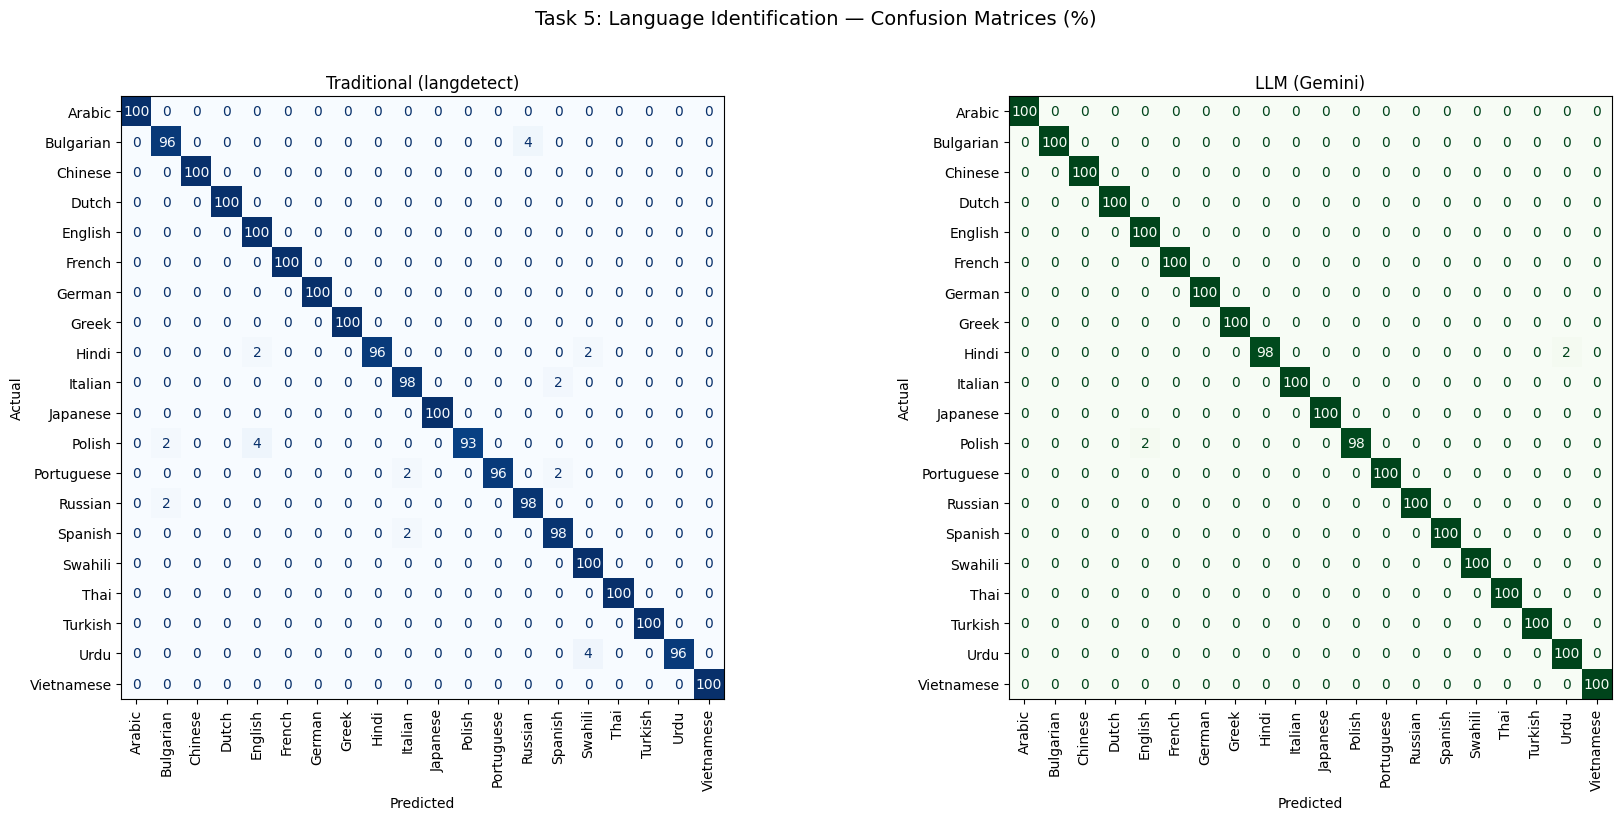

In [103]:
if trad and llm:
    lang_labels = sorted(set(row["actual"].strip() for row in trad))

    t_actual = [row["actual"].strip() for row in trad]
    t_pred = [row["predicted"].strip() for row in trad]

    llm_map_lang = {row["id"]: row["language"].strip() for row in llm}
    l_pred = [llm_map_lang.get(row["id"], "???").strip() for row in trad]

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    # Traditional — percentage confusion matrix (row-normalized)
    cm_trad = confusion_matrix(t_actual, t_pred, labels=lang_labels)
    cm_trad_pct = cm_trad.astype(float) / cm_trad.sum(axis=1, keepdims=True) * 100
    disp_trad = ConfusionMatrixDisplay(cm_trad_pct, display_labels=lang_labels)
    disp_trad.plot(ax=axes[0], cmap="Blues", colorbar=False, values_format=".0f", xticks_rotation=90)
    axes[0].set_title("Traditional (langdetect)")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")

    # LLM — percentage confusion matrix (row-normalized)
    cm_llm = confusion_matrix(t_actual, l_pred, labels=lang_labels)
    cm_llm_pct = cm_llm.astype(float) / cm_llm.sum(axis=1, keepdims=True) * 100
    disp_llm = ConfusionMatrixDisplay(cm_llm_pct, display_labels=lang_labels)
    disp_llm.plot(ax=axes[1], cmap="Greens", colorbar=False, values_format=".0f", xticks_rotation=90)
    axes[1].set_title("LLM (Gemini)")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("Actual")

    plt.suptitle("Task 5: Language Identification — Confusion Matrices (%)", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping — missing file(s)")

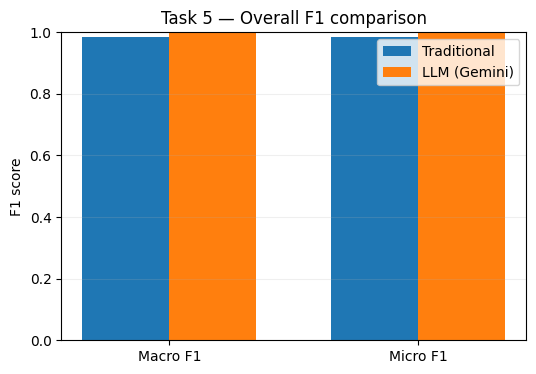

In [108]:
# Task 5 – Overall F1 comparison (macro & micro)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

trad_lang = load_csv("results/language_traditional.csv")
llm_lang = load_csv("llm_output/language.csv")

if trad_lang and llm_lang:
    gold_lang = [row["actual"].strip() for row in trad_lang]
    trad_pred_lang = [row["predicted"].strip() for row in trad_lang]

    llm_map_lang = {row["id"]: row["language"].strip() for row in llm_lang}
    llm_pred_lang = [llm_map_lang.get(row["id"], "???").strip() for row in trad_lang]

    n = min(len(gold_lang), len(trad_pred_lang), len(llm_pred_lang))
    gold_lang = gold_lang[:n]
    trad_pred_lang = trad_pred_lang[:n]
    llm_pred_lang = llm_pred_lang[:n]

    labels_lang = sorted(set(gold_lang))

    f1_trad_macro = f1_score(gold_lang, trad_pred_lang, labels=labels_lang, average="macro")
    f1_llm_macro = f1_score(gold_lang, llm_pred_lang, labels=labels_lang, average="macro")
    f1_trad_micro = f1_score(gold_lang, trad_pred_lang, labels=labels_lang, average="micro")
    f1_llm_micro = f1_score(gold_lang, llm_pred_lang, labels=labels_lang, average="micro")

    metrics = ["Macro F1", "Micro F1"]
    trad_vals = [f1_trad_macro, f1_trad_micro]
    llm_vals = [f1_llm_macro, f1_llm_micro]

    x = np.arange(len(metrics))
    width = 0.35

    plt.figure(figsize=(6, 4))
    plt.bar(x - width/2, trad_vals, width, label="Traditional")
    plt.bar(x + width/2, llm_vals, width, label="LLM (Gemini)")
    plt.xticks(x, metrics)
    plt.ylabel("F1 score")
    plt.ylim(0, 1.0)
    plt.title("Task 5 — Overall F1 comparison")
    plt.legend()
    plt.grid(axis="y", alpha=0.2)
    plt.show()
else:
    print("Missing language CSVs; run the earlier language cells first.")

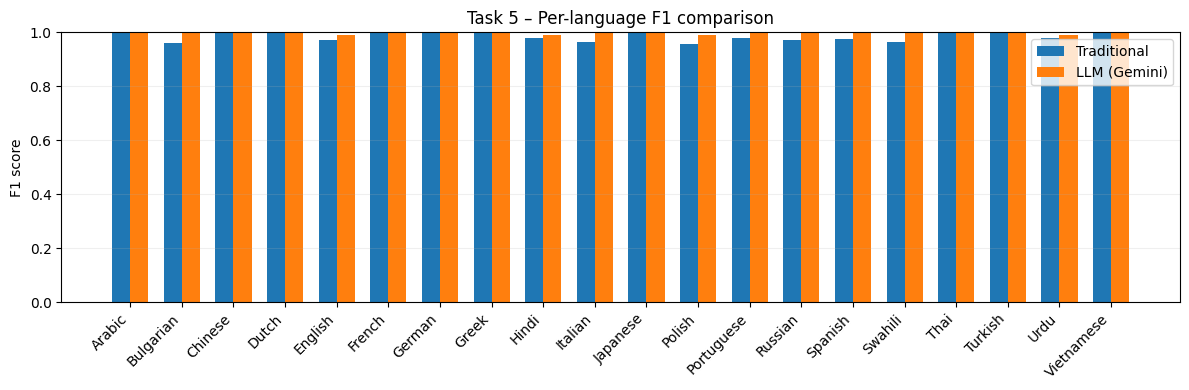

In [110]:
# Task 5 – Per-language F1 comparison
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support

# Assumes Task 5 overall F1 cell (gold_lang, trad_pred_lang, llm_pred_lang) has been run
if "gold_lang" in globals() and "trad_pred_lang" in globals() and "llm_pred_lang" in globals():
    labels = sorted(set(gold_lang))
    _, _, f1_trad_per, _ = precision_recall_fscore_support(
        gold_lang, trad_pred_lang, labels=labels, zero_division=0
    )
    _, _, f1_llm_per, _ = precision_recall_fscore_support(
        gold_lang, llm_pred_lang, labels=labels, zero_division=0
    )

    x = np.arange(len(labels))
    width = 0.35

    plt.figure(figsize=(12, 4))
    plt.bar(x - width/2, f1_trad_per, width, label="Traditional")
    plt.bar(x + width/2, f1_llm_per, width, label="LLM (Gemini)")
    plt.xticks(x, labels, rotation=45, ha="right")
    plt.ylabel("F1 score")
    plt.ylim(0, 1.0)
    plt.title("Task 5 – Per-language F1 comparison")
    plt.legend()
    plt.grid(axis="y", alpha=0.2)
    plt.tight_layout()
    plt.show()
else:
    print("Missing language variables; run the Task 5 F1-overall cell first.")

---
## Overall Summary

In [ ]:
summary_rows = []

# Sentiment
trad_s = load_csv("results/sentiment_traditional.csv")
llm_s = load_csv("llm_output/sentiment.csv")
if trad_s and llm_s:
    llm_map_s = {r["id"]: r["label"].strip().lower() for r in llm_s}
    agree_s = sum(1 for r in trad_s if r["label"].strip().lower() == llm_map_s.get(r["id"], ""))
    summary_rows.append({"Task": "Sentiment Analysis", "Metric": "Label Agreement",
                         "Match": agree_s, "Total": len(trad_s),
                         "Percentage": f"{accuracy(agree_s, len(trad_s))}%"})

# NER
trad_n = load_csv("results/ner_traditional.csv")
llm_n = load_csv("llm_output/ner.csv")
if trad_n and llm_n:
    llm_map_n = {r["id"]: r["entities"] for r in llm_n}
    tot_t, tot_o = 0, 0
    for r in trad_n:
        te = normalize_entities(r["entities"])
        le = normalize_entities(llm_map_n.get(r["id"], ""))
        tot_t += len(te); tot_o += len(te & le)
    denom_n = max(tot_t, 1)
    summary_rows.append({"Task": "NER", "Metric": "Entity Exact Match",
                         "Match": tot_o, "Total": denom_n,
                         "Percentage": f"{accuracy(tot_o, denom_n)}%"})

# POS
trad_p = load_csv("results/pos_traditional.csv")
llm_p = load_csv("llm_output/pos.csv")
if trad_p and llm_p:
    llm_map_p = {r["id"]: r["pos_tags"] for r in llm_p}
    tok_m, tok_t = 0, 0
    for r in trad_p:
        td = {}
        for pair in r["pos_tags"].split():
            if "/" in pair:
                parts = pair.rsplit("/", 1)
                td[parts[0].lower()] = parts[1]
        ld = {}
        for pair in llm_map_p.get(r["id"], "").split():
            if "/" in pair:
                parts = pair.rsplit("/", 1)
                ld[parts[0].lower()] = parts[1]
        for w, tag in td.items():
            if w in ld:
                tok_t += 1
                if ld[w] == tag:
                    tok_m += 1
    summary_rows.append({"Task": "POS Tagging", "Metric": "Token Tag Agreement",
                         "Match": tok_m, "Total": tok_t,
                         "Percentage": f"{accuracy(tok_m, tok_t)}%"})

# Topic
trad_tm = load_csv("results/topic_traditional.csv")
llm_tm = load_csv("llm_output/topic.csv")
if trad_tm and llm_tm:
    llm_map_tm = {r["id"]: r["topic"].strip() for r in llm_tm}
    tc_tm = sum(1 for r in trad_tm if r.get("predicted", r.get("topic", "")).strip().lower() == r["actual"].strip().lower())
    lc_tm = sum(1 for r in trad_tm if llm_map_tm.get(r["id"], "").lower() == r["actual"].strip().lower())
    summary_rows.append({"Task": "Topic (Traditional)", "Metric": "Accuracy vs Ground Truth",
                         "Match": tc_tm, "Total": len(trad_tm),
                         "Percentage": f"{accuracy(tc_tm, len(trad_tm))}%"})
    summary_rows.append({"Task": "Topic (LLM)", "Metric": "Accuracy vs Ground Truth",
                         "Match": lc_tm, "Total": len(trad_tm),
                         "Percentage": f"{accuracy(lc_tm, len(trad_tm))}%"})

# Language
trad_l = load_csv("results/language_traditional.csv")
llm_l = load_csv("llm_output/language.csv")
if trad_l and llm_l:
    llm_map_l = {r["id"]: r["language"].strip() for r in llm_l}
    tc = sum(1 for r in trad_l if r["predicted"].strip().lower() == r["actual"].strip().lower())
    lc = sum(1 for r in trad_l if llm_map_l.get(r["id"], "").lower() == r["actual"].strip().lower())
    summary_rows.append({"Task": "Language ID (Traditional)", "Metric": "Accuracy vs Ground Truth",
                         "Match": tc, "Total": len(trad_l),
                         "Percentage": f"{accuracy(tc, len(trad_l))}%"})
    summary_rows.append({"Task": "Language ID (LLM)", "Metric": "Accuracy vs Ground Truth",
                         "Match": lc, "Total": len(trad_l),
                         "Percentage": f"{accuracy(lc, len(trad_l))}%"})

if summary_rows:
    df_summary = pd.DataFrame(summary_rows)
    display(df_summary)

    # Save to CSV
    df_summary.to_csv("results/comparison_summary.csv", index=False)
    print("\nSaved to results/comparison_summary.csv")
else:
    print("No comparisons available. Make sure all files exist.")

,Task,Metric,Match,Total,Percentage
0,Sentiment Analysis,Label Agreement,12899,20000,64.5%
1,NER,Entity Exact Match,932,2422,38.5%
2,POS Tagging,Token Tag Agreement,11283,12610,89.5%
3,Topic (Traditional),Accuracy vs Ground Truth,885,1000,88.5%
4,Topic (LLM),Accuracy vs Ground Truth,885,1000,88.5%
5,Language ID (Traditional),Accuracy vs Ground Truth,985,1000,98.5%
6,Language ID (LLM),Accuracy vs Ground Truth,998,1000,99.8%



Saved to results/comparison_summary.csv
